In [ ]:
m1=1
m2=2
l1=0.5
l2=0.7
def f(t,x,y,xp,yp):
  (-m2*l1*)

In [ ]:
K0x = f(t,x,y,xp,yp)
K0y = g(t,x,y,xp,yp)
Q1x = xp + (h/2)*K0x
Q1y = yp + (h/2)*K0y
K1x = f(t+h/2,x+(h/2)*xp,y+(h/2)*yp,Q1x,Q1y)
K1y = g(t+h/2,x+(h/2)*xp,y+(h/2)*yp,Q1x,Q1y)
Q2x = xp + (h/2)*K1x
Q2y = yp + (h/2)*K1y
K2x = f(t+h/2,x+(h/2)*Q1x,y+(h/2)*Q1y,Q2x,Q2y)
K2y = g(t+h/2,x+(h/2)*Q1x,y+(h/2)*Q1y,Q2x,Q2y)
Q3x = xp + h*K2x
Q3y = yp + h*K2y
K3x = f(t+h, x+h*Q2x, y+h*Q2y, Q3x,Q3y)
K3y = g(t+h, x+h*Q2x, y+h*Q2y, Q3x,Q3y)

In [1]:
#Get theta1 acceleration
def theta1_acceleration(m1,m2,l1,l2,theta1,theta2,theta1_velocity,theta2_velocity,g):
    mass1 = -g*(2*m1 + m2)*np.sin(theta1)
    mass2 = -m2*g*np.sin(theta1 - 2*theta2)
    interaction = -2*np.sin(theta1 - theta2)*m2*np.cos(theta2_velocity**2*l2 + theta1_velocity**2*l1*np.cos(theta1 - theta2))
    normalization = l1*(2*m1 + m2 - m2*np.cos(2*theta1 - 2*theta2))

    theta1_ddot = (mass1 + mass2 + interaction)/normalization

    return theta1_ddot

#Get theta2 acceleration
def theta2_acceleration(m1,m2,l1,l2,theta1,theta2,theta1_velocity,theta2_velocity,g):
    system = 2*np.sin(theta1 - theta2)*(theta1_velocity**2*l1*(m1 + m2) + g*(m1 + m2)*np.cos(theta1) + theta2_velocity**2*l2*m2*np.cos(theta1 - theta2))
    normalization = l1*(2*m1 + m2 - m2*np.cos(2*theta1 - 2*theta2))

    theta2_ddot = system/normalization
    return theta2_ddot

#Update theta1
def theta1_update(m1,m2,l1,l2,theta1,theta2,theta1_velocity,theta2_velocity,g,time_step):
    #Numerical Integration
    theta1_velocity += time_step*theta1_acceleration(m1,m2,l1,l2,theta1,theta2,theta1_velocity,theta2_velocity,g)
    theta1 += time_step*theta1_velocity
    return theta1, theta1_velocity

#Update theta2
def theta2_update(m1,m2,l1,l2,theta1,theta2,theta1_velocity,theta2_velocity,g,time_step):
    #Numerical Integration
    theta2_velocity += time_step*theta2_acceleration(m1,m2,l1,l2,theta1,theta2,theta1_velocity,theta2_velocity,g)
    theta2 += time_step*theta2_velocity
    return theta2, theta2_velocity

#Run full double pendulum
def double_pendulum(m1,m2,l1,l2,theta1,theta2,theta1_velocity,theta2_velocity,g,time_step,time_span):
    theta1_list = [theta1]
    theta2_list = [theta2]

    for t in time_span:
        theta1, theta1_velocity = theta1_update(m1,m2,l1,l2,theta1,theta2,theta1_velocity,theta2_velocity,g,time_step)
        theta2, theta2_velocity = theta2_update(m1,m2,l1,l2,theta1,theta2,theta1_velocity,theta2_velocity,g,time_step)

        theta1_list.append(theta1)
        theta2_list.append(theta2)

    x1 = l1*np.sin(theta1_list) #Pendulum 1 x
    y1 = -l1*np.cos(theta1_list) #Pendulum 1 y

    x2 = l1*np.sin(theta1_list) + l2*np.sin(theta2_list) #Pendulum 2 x
    y2 = -l1*np.cos(theta1_list) - l2*np.cos(theta2_list) #Pendulum 2 y

    return x1,y1,x2,y2

In [3]:
import numpy as np

#Define system parameters
g = 9.8 #m/s^2

m1 = 1 #kg
m2 = 1 #kg

l1 = 1 #m
l2 = 1 #m

theta1 = np.radians(90)
theta2 = np.radians(45)

theta1_velocity = 0 #m/s
theta2_velocity = 0 #m/s

theta1_list = [theta1]
theta2_list = [theta2]

time_step = 20/300

time_span = np.linspace(0,20,300)
x1,y1,x2,y2 = double_pendulum(m1,m2,l1,l2,theta1,theta2,theta1_velocity,theta2_velocity,g,time_step,time_span)

In [4]:
def theta1_acceleration(m1,m2,l1,l2,theta1,theta2,theta1_velocity,theta2_velocity,g):
    mass1 = -g*(2*m1 + m2)*np.sin(theta1)
    mass2 = -m2*g*np.sin(theta1 - 2*theta2)
    interaction = -2*np.sin(theta1 - theta2)*m2*np.cos(theta2_velocity**2*l2 + theta1_velocity**2*l1*np.cos(theta1 - theta2))
    normalization = l1*(2*m1 + m2 - m2*np.cos(2*theta1 - 2*theta2))

    theta1_ddot = (mass1 + mass2 + interaction)/normalization

    return theta1_ddot

def theta2_acceleration(m1,m2,l1,l2,theta1,theta2,theta1_velocity,theta2_velocity,g):
    system = 2*np.sin(theta1 - theta2)*(theta1_velocity**2*l1*(m1 + m2) + g*(m1 + m2)*np.cos(theta1) + theta2_velocity**2*l2*m2*np.cos(theta1 - theta2))
    normalization = l1*(2*m1 + m2 - m2*np.cos(2*theta1 - 2*theta2))

    theta2_ddot = system/normalization
    return theta2_ddot

def theta1_update(m1,m2,l1,l2,theta1,theta2,theta1_velocity,theta2_velocity,g,time_step):

    theta1_velocity += time_step*theta1_acceleration(m1,m2,l1,l2,theta1,theta2,theta1_velocity,theta2_velocity,g)
    theta1 += time_step*theta1_velocity
    return theta1, theta1_velocity

def theta2_update(m1,m2,l1,l2,theta1,theta2,theta1_velocity,theta2_velocity,g,time_step):

    theta2_velocity += time_step*theta2_acceleration(m1,m2,l1,l2,theta1,theta2,theta1_velocity,theta2_velocity,g)
    theta2 += time_step*theta2_velocity
    return theta2, theta2_velocity

def double_pendulum(m1,m2,l1,l2,theta1,theta2,theta1_velocity,theta2_velocity,g,time_step,time_span):
    theta1_list = [theta1]
    theta2_list = [theta2]

    for t in time_span:
        theta1, theta1_velocity = theta1_update(m1,m2,l1,l2,theta1,theta2,theta1_velocity,theta2_velocity,g,time_step)
        theta2, theta2_velocity = theta2_update(m1,m2,l1,l2,theta1,theta2,theta1_velocity,theta2_velocity,g,time_step)

        theta1_list.append(theta1)
        theta2_list.append(theta2)

    x1 = l1*np.sin(theta1_list)
    y1 = -l1*np.cos(theta1_list)

    x2 = l1*np.sin(theta1_list) + l2*np.sin(theta2_list)
    y2 = -l1*np.cos(theta1_list) - l2*np.cos(theta2_list)

    return x1,y1,x2,y2

In [5]:
#Define system parameters, run double pendulum
g = 9.8 #m/s^2

m1 = 1 #kg
m2 = 1 #kg

l1 = 1 #m
l2 = 1 #m

theta1 = np.radians(90)
theta2 = np.radians(45)

theta1_velocity = 0 #m/s
theta2_velocity = 0 #m/s

theta1_list = [theta1]
theta2_list = [theta2]

time_step = 20/300

time_span = np.linspace(0,20,300)
for t in time_span:
    theta1, theta1_velocity = theta1_update(m1,m2,l1,l2,theta1,theta2,theta1_velocity,theta2_velocity,g,time_step)
    theta2, theta2_velocity = theta2_update(m1,m2,l1,l2,theta1,theta2,theta1_velocity,theta2_velocity,g,time_step)

    theta1_list.append(theta1)
    theta2_list.append(theta2)

x1 = l1*np.sin(theta1_list)
y1 = -l1*np.cos(theta1_list)

x2 = l1*np.sin(theta1_list) + l2*np.sin(theta2_list)
y2 = -l1*np.cos(theta1_list) - l2*np.cos(theta2_list)

In [8]:
def makeGif(x,y,name):
    !mkdir frames

    counter=0
    images = []
    for i in range(0,len(x)):
        plt.figure(figsize = (6,6))

        plt.plot([0,x[i]],[0,y[i]], "o-", color = "b", markersize = 7, linewidth=.7 )
        plt.title("Pendulum")
        plt.xlim(-1.1,1.1)
        plt.ylim(-1.1,1.1)
        plt.savefig("frames/" + str(counter)+ ".png")
        images.append(imageio.imread("frames/" + str(counter)+ ".png"))
        counter += 1
        plt.close()

    imageio.mimsave(name, images)

    !rm -r frames

In [10]:
from matplotlib import pyplot as plt
import imageio
#Make Gif
!mkdir frames

counter=0
images = []
for i in range(0,len(x1)):
    plt.figure(figsize = (6,6))

    plt.figure(figsize = (6,6))
    plt.plot([0,x1[i]],[0,y1[i]], "o-", color = "b", markersize = 7, linewidth=.7 )
    plt.plot([x1[i],x2[i]],[y1[i],y2[i]], "o-", color = "b", markersize = 7, linewidth=.7 )
    plt.title("Double Pendulum")
    plt.xlim(-2.1,2.1)
    plt.ylim(-2.1,2.1)
    plt.savefig("frames/" + str(counter)+ ".png")
    images.append(imageio.imread("frames/" + str(counter)+ ".png"))
    counter += 1
    plt.close()

imageio.mimsave("double_pendulum.gif", images)

!rm -r frames

mkdir: cannot create directory ‘frames’: File exists


<ipython-input-10-72b618911e7c>:18: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images.append(imageio.imread("frames/" + str(counter)+ ".png"))
<ipython-input-10-72b618911e7c>:11: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize = (6,6))
<ipython-input-10-72b618911e7c>:9: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rc

<Figure size 600x600 with 0 Axes>

<Figure size 600x600 with 0 Axes>

<Figure size 600x600 with 0 Axes>

...

<Figure size 600x600 with 0 Axes>

<Figure size 600x600 with 0 Axes>

<Figure size 600x600 with 0 Axes>

<Figure size 600x600 with 0 Axes>

<Figure size 600x600 with 0 Axes>

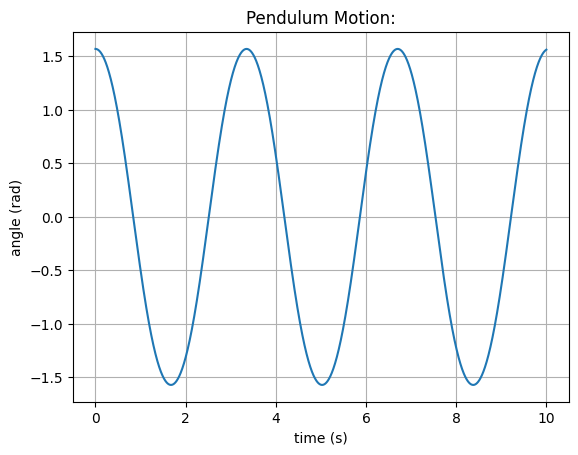

In [11]:
import numpy as np
import matplotlib.pyplot as plt
m = 3.0
g = 9.8
r = 2.0
I = 12.0
h = 0.0025
l=2.0
cycle = 10.0
t = np.arange(0, cycle, h)
n = (int)((cycle)/h)
initial_angle = 90.0
y=np.zeros(n)
v=np.zeros(n)
def accel(theta):
  return -(m*g*r/I)*np.sin(theta)
y[0] = np.radians(initial_angle)
v[0] = np.radians(0.0)
for i in range(0, n-1):
    k1y = h*v[i]
    k1v = h*accel(y[i])
    k2y = h*(v[i]+0.5*k1v)
    k2v = h*accel(y[i]+0.5*k1y)
    k3y = h*(v[i]+0.5*k2v)
    k3v = h*accel(y[i]+0.5*k2y)
    k4y = h*(v[i]+k3v)
    k4v = h*accel(y[i]+k3y)
    y[i+1] = y[i] + (k1y + 2 * k2y + 2 * k3y + k4y) / 6.0
    v[i+1] = v[i] + (k1v + 2 * k2v + 2 * k3v + k4v) / 6.0

plt.plot(t, y)
plt.title('Pendulum Motion:')
plt.xlabel('time (s)')
plt.ylabel('angle (rad)')
plt.grid(True)
plt.show()